Cell 1 — Setup

In [1]:
'''!pip install torch torchvision tqdm opencv-python --quiet'''

import os, glob, math, random, numpy as np, cv2, torch
import torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm


c:\Users\ASUS\anaconda3\envs\trading\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cell 2 — Paths and GPU

In [24]:
# --- set data directory
DATA_DIR = "M:/MIAMI/555"   # change to folder containing 00000_radar.npz, 00000_pose.npz, etc.
OUT_DIR  = "M:/MIAMI/555/checkpoints"
os.makedirs(OUT_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


In [ ]:
# --- dataset constants
CAMERA_WIDTH = 640
CAMERA_HEIGHT = 480
LOG_SCALE_INPUT = True


Cell 3 — Soft-Argmax and Model

In [25]:
# --- Soft-Argmax
class SoftArgmax2D(nn.Module):
    def __init__(self, beta=1.0):
        super().__init__()
        self.beta = beta
    def forward(self, hms):
        B,K,H,W = hms.shape
        h = torch.softmax(hms.view(B*K, -1) * self.beta, dim=-1).view(B*K,1,H,W)
        xs = torch.linspace(0, W-1, W, device=hms.device).view(1,1,1,W)
        ys = torch.linspace(0, H-1, H, device=hms.device).view(1,1,H,1)
        x = torch.sum(h*xs, dim=[2,3]).view(B,K,1)
        y = torch.sum(h*ys, dim=[2,3]).view(B,K,1)
        coords = torch.cat([x,y], dim=-1)
        conf,_ = torch.max(h.view(B*K,-1), dim=-1)
        return coords, conf.view(B,K)

# --- simple conv backbone
def conv_bn_relu(cin, cout, k=3, s=1, p=1):
    return nn.Sequential(nn.Conv2d(cin, cout, k, s, p, bias=False),
                         nn.BatchNorm2d(cout),
                         nn.ReLU(inplace=True))

class RadarPoseNet(nn.Module):
    def __init__(self, num_kp=17, in_ch=2, base=64, out_res=128):
        super().__init__()
        self.out_res = out_res
        self.backbone = nn.Sequential(
            conv_bn_relu(in_ch, base, 7, 2, 3),
            conv_bn_relu(base, base, 3, 1, 1),
            conv_bn_relu(base, base*2, 3, 2, 1),
            conv_bn_relu(base*2, base*2, 3, 1, 1),
            conv_bn_relu(base*2, base*4, 3, 2, 1),
            conv_bn_relu(base*4, base*4, 3, 1, 1),
            conv_bn_relu(base*4, base*4, 3, 1, 1)
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(base*4, base*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*2), nn.ReLU(True),
            nn.ConvTranspose2d(base*2, base, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base), nn.ReLU(True),
            nn.ConvTranspose2d(base, base, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base), nn.ReLU(True)
        )
        self.hm_head = nn.Conv2d(base, num_kp, 1)
        self.soft = SoftArgmax2D(beta=10.0)
    def forward(self, x):
        f = self.backbone(x)
        h = self.deconv(f)
        hm = self.hm_head(h)
        coords, conf = self.soft(hm)
        return hm, coords, conf


Cell 4 — Dataset loader

In [26]:

def load_radar_frame(root, fid, out_res, log_scale=True):
    with np.load(os.path.join(root, f"{fid}_radar.npz")) as data:
        hm_hori = data["hm_hori"].astype(np.float32)
        hm_vert = data["hm_vert"].astype(np.float32)
    res_hori = cv2.resize(hm_hori, (out_res, out_res), interpolation=cv2.INTER_LINEAR)
    res_vert = cv2.resize(hm_vert, (out_res, out_res), interpolation=cv2.INTER_LINEAR)
    inp = np.stack([res_hori, res_vert], axis=0)
    if log_scale:
        inp = np.log1p(np.clip(inp, a_min=0.0, a_max=None))
    return inp

def compute_channel_stats(root, ids, out_res, cache_path=None, log_scale=True):
    if cache_path and os.path.exists(cache_path):
        cached = np.load(cache_path)
        mean, std = cached["mean"], cached["std"]
        cached.close()
        return mean, std
    sum_c = np.zeros(2, dtype=np.float64)
    sumsq_c = np.zeros(2, dtype=np.float64)
    total_px = 0
    for fid in tqdm(ids, desc="stats", leave=False):
        frame = load_radar_frame(root, fid, out_res, log_scale=log_scale)
        reshaped = frame.reshape(2, -1)
        sum_c += reshaped.sum(axis=1)
        sumsq_c += (reshaped ** 2).sum(axis=1)
        total_px += frame.shape[1] * frame.shape[2]
    denom = max(total_px, 1)
    mean = sum_c / denom
    var = sumsq_c / denom - mean ** 2
    std = np.sqrt(np.clip(var, 1e-6, None))
    mean = mean.astype(np.float32)
    std = std.astype(np.float32)
    if cache_path:
        np.savez(cache_path, mean=mean, std=std)
    return mean, std

class RadarPoseDataset(Dataset):
    def __init__(self, data_dir, ids, out_res=128, sigma=2.0, mean=None, std=None, log_scale=True):
        self.root, self.ids, self.out_res, self.sigma = data_dir, ids, out_res, sigma
        self.mean = np.array(mean, dtype=np.float32) if mean is not None else None
        self.std = np.array(std, dtype=np.float32) if std is not None else None
        self.log_scale = log_scale
    def __len__(self): return len(self.ids)
    def _make_heatmaps(self, xy, vis):
        K,H,W = xy.shape[0], self.out_res, self.out_res
        yy,xx = np.meshgrid(np.arange(H),np.arange(W),indexing="ij")
        hms = np.zeros((K,H,W),np.float32)
        for k in range(K):
            if vis[k]<0.5: continue
            x, y = xy[k]
            g=np.exp(-((yy-y)**2+(xx-x)**2)/(2*self.sigma**2))
            hms[k]=g
        return hms
    def __getitem__(self,i):
        fid=self.ids[i]
        inp = load_radar_frame(self.root, fid, self.out_res, log_scale=self.log_scale)
        if self.mean is not None and self.std is not None:
            inp = (inp - self.mean[:, None, None]) / (self.std[:, None, None] + 1e-6)
        else:
            ch_mean = inp.mean(axis=(1,2), keepdims=True)
            ch_std = inp.std(axis=(1,2), keepdims=True) + 1e-6
            inp = (inp - ch_mean) / ch_std
        inp = np.nan_to_num(inp, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

        with np.load(os.path.join(self.root,f"{fid}_pose.npz")) as pose_file:
            pose = pose_file["kp"]
        if pose.ndim == 3:
            kp = pose[0]
        else:
            kp = pose.astype(np.float32)
        xy = kp[:,:2].astype(np.float32)
        vis = (kp[:,2] > 0).astype(np.float32)
        scale_x = self.out_res / float(CAMERA_WIDTH)
        scale_y = self.out_res / float(CAMERA_HEIGHT)
        xy[:,0] *= scale_x
        xy[:,1] *= scale_y
        xy[:,0] = np.clip(xy[:,0], 0.0, self.out_res - 1)
        xy[:,1] = np.clip(xy[:,1], 0.0, self.out_res - 1)
        hms=self._make_heatmaps(xy,vis)
        return {"input":torch.from_numpy(inp),
                "target_hm":torch.from_numpy(hms.astype(np.float32)),
                "target_xy":torch.from_numpy(xy.astype(np.float32)),
                "vis":torch.from_numpy(vis.astype(np.float32)),
                "fid":fid}



Cell 5 — Loss + Train/Eval functions

In [27]:
def heatmap_mse(pred,tgt,vis):
    w=vis.view(vis.size(0),vis.size(1),1,1)
    return F.mse_loss(pred*w,tgt*w,reduction="sum")/(w.sum()+1e-6)
def coord_l1(pred,tgt,vis):
    w=vis.unsqueeze(-1)
    return F.l1_loss(pred*w,tgt*w,reduction="sum")/(w.sum()+1e-6)

@torch.no_grad()
def evaluate(model,loader,device):
    model.eval(); tot=0; cnt=0
    for b in loader:
        x=b["input"].to(device)
        y=b["target_xy"].to(device)
        vis=b["vis"].to(device)
        _,p,_=model(x)
        w=vis.unsqueeze(-1)
        tot+=torch.abs((p-y)*w).sum().item()
        cnt+=w.sum().item()
    return tot/(cnt+1e-6)

def train_one_epoch(model,loader,opt,device,lam=0.5,epoch=None):
    model.train(); loss_sum=0
    pbar = tqdm(loader, total=len(loader), leave=False, desc=(f"Epoch {epoch:03d} [train]" if epoch is not None else "Train"))
    for b in pbar:
        x=b["input"].to(device); th=b["target_hm"].to(device)
        ty=b["target_xy"].to(device); vis=b["vis"].to(device)
        opt.zero_grad()
        ph,px,_=model(x)
        L=heatmap_mse(ph,th,vis)+lam*coord_l1(px,ty,vis)
        L.backward(); opt.step()
        loss_sum+=L.item()*x.size(0)
        pbar.set_postfix(loss=float(L.item()))
    return loss_sum/max(len(loader.dataset),1)



Cell 6 — Discover dataset IDs and split

In [28]:
# Recursively discover radar files in nested subfolders
files = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*_radar.npz"), recursive=True))

# Build IDs as relative paths without the trailing suffix '_radar.npz'
ids = []
for f in files:
    rel = os.path.relpath(f, DATA_DIR)
    if rel.endswith('_radar.npz'):
        ids.append(rel[:-len('_radar.npz')])

random.seed(42)
random.shuffle(ids)

n_total = len(ids)
split_train = int(0.8 * n_total)
split_val = int(0.9 * n_total)

ids_tr = ids[:split_train]
ids_va = ids[split_train:split_val]
ids_te = ids[split_val:]

if len(ids_te) == 0 and len(ids_va) > 0:
    ids_te = ids_va[-1:]
    ids_va = ids_va[:-1]
elif len(ids_te) == 0 and len(ids_tr) > 1:
    ids_te = ids_tr[-1:]
    ids_tr = ids_tr[:-1]

print(f"{len(ids_tr)} train, {len(ids_va)} val, {len(ids_te)} test frames found.")



97111 train, 10791 val frames found.


Cell 7 — Dataloaders + Model + Optimizer

In [29]:
BATCH = 32; EPOCHS = 120; LR = 3e-4; OUT_RES = 128; PATIENCE = 15

stats_cache = os.path.join(OUT_DIR, f"radar_norm_res{OUT_RES}_log{int(LOG_SCALE_INPUT)}.npz")
mean, std = compute_channel_stats(DATA_DIR, ids_tr, OUT_RES, cache_path=stats_cache, log_scale=LOG_SCALE_INPUT)
print(f"Norm stats (mean={mean}, std={std})")

ds_tr = RadarPoseDataset(DATA_DIR, ids_tr, OUT_RES, mean=mean, std=std, log_scale=LOG_SCALE_INPUT)
ds_va = RadarPoseDataset(DATA_DIR, ids_va, OUT_RES, mean=mean, std=std, log_scale=LOG_SCALE_INPUT)
ds_te = RadarPoseDataset(DATA_DIR, ids_te, OUT_RES, mean=mean, std=std, log_scale=LOG_SCALE_INPUT)

dl_tr = DataLoader(ds_tr, BATCH, shuffle=True, num_workers=0, pin_memory=True)
dl_va = DataLoader(ds_va, BATCH, shuffle=False, num_workers=0)
dl_te = DataLoader(ds_te, BATCH, shuffle=False, num_workers=0)

model = RadarPoseNet(num_kp=17, in_ch=2, base=64, out_res=OUT_RES).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5, min_lr=1e-6, verbose=True)



Cell 8 — Training loop

In [31]:
@torch.no_grad()
def _eval_pck(model, loader, device, alpha=0.05):
    model.eval(); correct=0; total=0
    H = W = getattr(model, 'out_res', 128)
    thresh = alpha*max(H, W)
    for b in loader:
        x=b['input'].to(device); y=b['target_xy'].to(device); vis=b['vis'].to(device)
        _,p,_=model(x)
        d=torch.norm((p-y),dim=-1); m=(vis>0.5)
        correct += ((d<thresh)*m).sum().item(); total += m.sum().item()
    return correct/max(total,1)

best=float('inf'); no_improve=0
for ep in range(1,EPOCHS+1):
    tr=train_one_epoch(model,dl_tr,opt,device,epoch=ep)
    val=evaluate(model,dl_va,device)
    val_pck=_eval_pck(model, dl_va, device, alpha=0.05)
    sch.step(val)
    lr=opt.param_groups[0]['lr']
    print(f"Epoch {ep:03d} | lr {lr:.2e} | train {tr:.4f} | val MAE(px) {val:.3f} | PCK@0.05 {val_pck:.3f}")
    if val < best - 1e-3:
        best=val; no_improve=0
        torch.save({"model":model.state_dict(),"out_res":OUT_RES}, os.path.join(OUT_DIR,"radar_pose_best.pt"))
    else:
        no_improve+=1
    if no_improve>=PATIENCE:
        print(f'Early stopping at epoch {ep} (no improvement {PATIENCE} epochs).')
        break
print("Best val MAE:",best)

best_ckpt = os.path.join(OUT_DIR, "radar_pose_best.pt")
if os.path.exists(best_ckpt):
    ckpt = torch.load(best_ckpt, map_location=device)
    model.load_state_dict(ckpt["model"])
    model.eval()
    if len(ids_te) > 0:
        test_mae = evaluate(model, dl_te, device)
        test_pck = _eval_pck(model, dl_te, device, alpha=0.05)
        print(f"Test MAE(px) {test_mae:.3f} | PCK@0.05 {test_pck:.3f}")



KeyboardInterrupt: 

Cell 9 — Quick inference test

In [ ]:
ckpt = torch.load(os.path.join(OUT_DIR, "radar_pose_best.pt"), map_location=device)

model.load_state_dict(ckpt["model"]); model.eval()

sample=ds_va[0]
x=sample["input"].unsqueeze(0).to(device)
_,pred,conf=model(x)
print("Predicted coords (heatmap space):", pred[0].detach().cpu().numpy()[:5])
print("Conf:", conf[0].detach().cpu().numpy()[:5])



Predicted coords (heatmap space): [[63.62618  63.4239  ]
 [63.41124  63.660522]
 [64.10365  63.189266]
 [62.96592  63.933117]
 [64.474464 63.00355 ]]
Conf: [1.0174480e-04 1.3164610e-04 8.7020904e-05 1.5887356e-04 7.9595280e-05]


C:\Users\ASUS\AppData\Local\Temp\ipykernel_8536\816015463.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(OUT_DIR, "radar_pose_best.pt"), 

Cell — PCK metric

In [ ]:
@torch.no_grad()
def evaluate_pck(model, loader, device, alpha=0.05):
    model.eval(); correct=0; total=0
    H = W = getattr(model, 'out_res', 128)
    thresh = alpha*max(H, W)
    for b in loader:
        x=b['input'].to(device)
        y=b['target_xy'].to(device)
        vis=b['vis'].to(device)
        _,p,_=model(x)
        d=torch.norm((p-y),dim=-1)
        m=(vis>0.5)
        correct += ((d<thresh)*m).sum().item()
        total += m.sum().item()
    return correct/max(total,1)

val_pck = evaluate_pck(model, dl_va, device, alpha=0.05)
print(f'Val PCK@0.05: {val_pck:.3f}')
if len(ids_te) > 0:
    test_pck = evaluate_pck(model, dl_te, device, alpha=0.05)
    print(f'Test PCK@0.05: {test_pck:.3f}')



Val PCK@0.05: 0.000


Cell — Prediction visualization

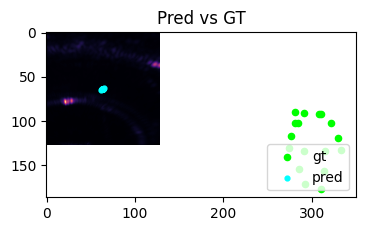

In [ ]:
import matplotlib.pyplot as plt
def show_sample(sample):
    img = sample['input'].numpy().sum(axis=0)
    H,W = img.shape
    x = sample['input'].unsqueeze(0).to(device)
    _,pred,_ = model(x)
    pred = pred[0].detach().cpu().numpy()
    gt = sample['target_xy'].numpy()
    vis = sample['vis'].numpy()>0.5
    plt.figure(figsize=(4,4)); plt.imshow(img, cmap='magma');
    plt.scatter(gt[vis,0], gt[vis,1], c='lime', s=20, label='gt');
    plt.scatter(pred[vis,0], pred[vis,1], c='cyan', s=12, label='pred');
    plt.legend(loc='lower right'); plt.title('Pred vs GT'); plt.show()

show_sample(ds_va[0])
